In [1]:
import pandas as pd  # voor werken met tabellen
import numpy as np  # voor berekeningen
from sklearn.model_selection import train_test_split  # data splitsen in train en test
from sklearn.preprocessing import OneHotEncoder  # categorische kolommen omzetten naar 0/1
from sklearn.compose import ColumnTransformer  # preprocessing combineren
from sklearn.pipeline import Pipeline  # preprocessing + model samenvoegen
from sklearn.tree import DecisionTreeClassifier  # decision tree model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay  # evaluatie metrics
import matplotlib.pyplot as plt  # voor grafieken

In [2]:
df = pd.read_excel('AmesHousing.xlsx', sheet_name='AmesHousing')  # excel bestand inladen
print(df.columns.tolist())  # kolomnamen bekijken
df.head()  # eerste 5 rijen bekijken

['ID', 'SalePrice', 'Garage', 'Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Lot Area', 'Year Built', 'Full Bath', 'Bedroom AbvGr', 'Neighborhood', 'House Style']


,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story


In [3]:
features = ['Overall Qual', 'Gr Liv Area', 'Neighborhood']  # gekozen features
X = df[features]  # feature matrix maken

y_bin = df['Garage'].map({'yes': 1, 'no': 0})  # garage omzetten naar 1 en 0
y_multi = df['Overall Qual']  # kwaliteit als multi-class target

In [4]:
categorical_features = ['Neighborhood']  # categorische kolom
numeric_features = ['Overall Qual', 'Gr Liv Area']  # numerieke kolommen

preprocessor = ColumnTransformer(  # preprocessing maken
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),  # tekst omzetten naar 0/1
        ('num', 'passthrough', numeric_features)  # cijfers laten zoals ze zijn
    ])

In [5]:
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(  # split voor binair model
    X, y_bin, test_size=0.2, random_state=42)  # 80% train 20% test

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(  # split voor multi model
    X, y_multi, test_size=0.2, random_state=42)  # zelfde random state

In [6]:
model = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)  # decision tree maken

pipeline = Pipeline(steps=[  # pipeline maken
    ('preprocessing', preprocessor),  # eerst preprocessing
    ('classifier', model)  # daarna model
])

pipeline.fit(X_train_bin, y_train_bin)  # model trainen

y_pred_bin = pipeline.predict(X_test_bin)  # voorspellingen maken

acc_bin = accuracy_score(y_test_bin, y_pred_bin)  # accuracy berekenen
prec_bin = precision_score(y_test_bin, y_pred_bin)  # precision berekenen
rec_bin = recall_score(y_test_bin, y_pred_bin)  # recall berekenen
f1_bin = f1_score(y_test_bin, y_pred_bin)  # f1 score berekenen

print("Binair model resultaten:")
print(acc_bin, prec_bin, rec_bin, f1_bin)  # scores printen

Binair model resultaten:
0.9402730375426621 0.9524647887323944 0.9854280510018215 0.9686660698299016


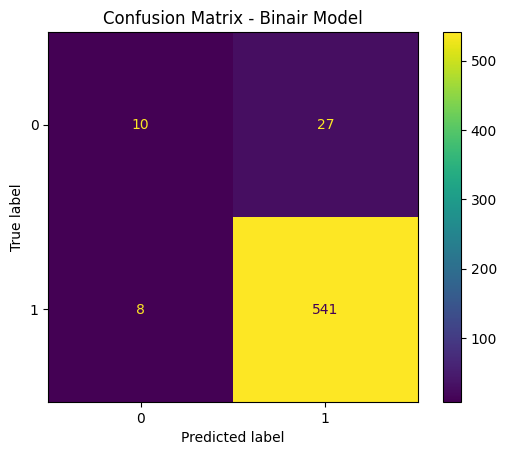

In [7]:
cm_bin = confusion_matrix(y_test_bin, y_pred_bin)  # confusion matrix maken
ConfusionMatrixDisplay(cm_bin).plot()  # matrix plotten
plt.title("Confusion Matrix - Binair Model")  # titel
plt.show()  # plot tonen

541 --> model zei “garage” en dat klopt.

10 --> model zei “geen garage” en dat klopt.

27--> model zei “garage”, maar klopt niet.

8--> model zei “geen garage”, maar er was wel garage

In [8]:
pipeline.fit(X_train_multi, y_train_multi)  # model opnieuw trainen

y_pred_multi = pipeline.predict(X_test_multi)  # voorspellingen maken

acc_multi = accuracy_score(y_test_multi, y_pred_multi)  # accuracy
prec_multi = precision_score(y_test_multi, y_pred_multi, average='weighted')  # weighted precision
rec_multi = recall_score(y_test_multi, y_pred_multi, average='weighted')  # weighted recall
f1_multi = f1_score(y_test_multi, y_pred_multi, average='weighted')  # weighted f1

print("Multi-class model resultaten:")
print(acc_multi, prec_multi, rec_multi, f1_multi)  # scores printen

Multi-class model resultaten:
1.0 1.0 1.0 1.0


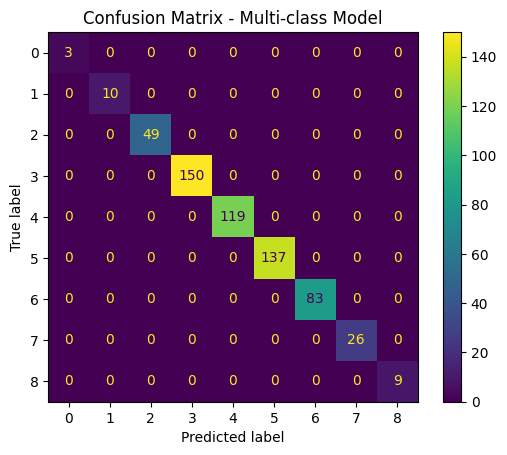

In [9]:
cm_multi = confusion_matrix(y_test_multi, y_pred_multi)  # confusion matrix maken
ConfusionMatrixDisplay(cm_multi).plot()  # plotten
plt.title("Confusion Matrix - Multi-class Model")  # titel
plt.show()  # tonen

Alle waarden staan op de diagonaal van de confusion matrix, wat betekent dat de voorspelde klasse 'kwaliteit' exact gelijk is aan de werkelijke klasse. Daarom classificeert het model alle huizen correct

In [10]:
all_results = []  # lege lijst om alle experiment resultaten op te slaan


def run_tree_experiment(name, max_depth=None, min_samples_split=2, 
                        min_samples_leaf=1, criterion='gini',
                        class_weight=None, features_used=features):
    # functie om makkelijk meerdere decision tree experimenten te draaien
    
    X_exp = df[features_used]  # gekozen features pakken
    y_exp = y_bin  # binaire target gebruiken
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_exp, y_exp, test_size=0.2, random_state=42)  # data splitsen
    
    categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()  # categorische kolommen zoeken
    numeric_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()  # numerieke kolommen zoeken
    
    preprocessor_exp = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),  # tekst omzetten naar 0/1
            ('num', 'passthrough', numeric_cols)  # cijfers laten zoals ze zijn
        ]
    )
    
    model_exp = DecisionTreeClassifier(
        max_depth=max_depth,  # maximale diepte van de boom
        min_samples_split=min_samples_split,  # minimum aantal samples om te splitsen
        min_samples_leaf=min_samples_leaf,  # minimum aantal samples per leaf
        criterion=criterion,  # gini of entropy
        class_weight=class_weight,  # voor class imbalance
        random_state=42  # vaste random state
    )
    
    pipeline_exp = Pipeline(steps=[
        ('preprocessing', preprocessor_exp),  # eerst preprocessing
        ('classifier', model_exp)  # daarna model
    ])
    
    pipeline_exp.fit(X_train, y_train)  # model trainen
    y_pred = pipeline_exp.predict(X_test)  # voorspellingen maken
    
    all_results.append({  # resultaten opslaan
        "Experiment": name,
        "max_depth": max_depth,
        "min_samples_split": min_samples_split,
        "min_samples_leaf": min_samples_leaf,
        "criterion": criterion,
        "class_weight": class_weight,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

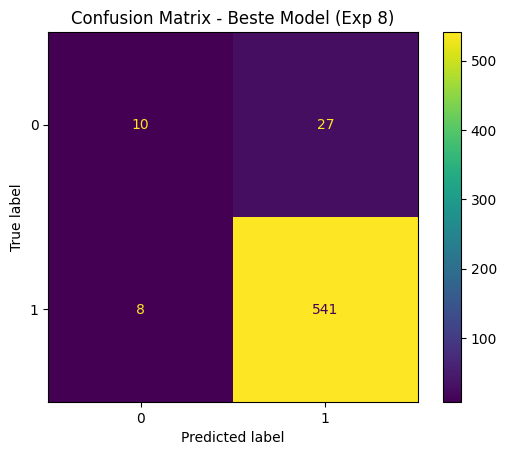

Accuracy: 0.9402730375426621
Precision: 0.9524647887323944
Recall: 0.9854280510018215
F1: 0.9686660698299016


In [11]:
# Beste model opnieuw trainen (Exp 8)

best_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=1,
    criterion='gini',
    random_state=42
)

best_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', best_model)
])

# Trainen
best_pipeline.fit(X_train_bin, y_train_bin)

# Voorspellingen maken
y_pred_best = best_pipeline.predict(X_test_bin)

# Confusion matrix maken
cm_best = confusion_matrix(y_test_bin, y_pred_best)

# Visualiseren
ConfusionMatrixDisplay(cm_best).plot()
plt.title("Confusion Matrix - Beste Model (Exp 8)")
plt.show()

# Metrics opnieuw tonen
print("Accuracy:", accuracy_score(y_test_bin, y_pred_best))
print("Precision:", precision_score(y_test_bin, y_pred_best))
print("Recall:", recall_score(y_test_bin, y_pred_best))
print("F1:", f1_score(y_test_bin, y_pred_best))

In [12]:
# Exp 1: basis model zonder beperkingen
run_tree_experiment("Exp 1: baseline",
                    max_depth=None,
                    min_samples_split=2)


# Exp 2: diepere boom met minder makkelijke splits
run_tree_experiment("Exp 2: depth=10 split=5",
                    max_depth=10,
                    min_samples_split=5)


# verschillende dieptes testen
run_tree_experiment("Exp 3: depth=3", max_depth=3)  # kleine boom
run_tree_experiment("Exp 4: depth=7", max_depth=7)  # middel
run_tree_experiment("Exp 5: depth=15", max_depth=15)  # diep
run_tree_experiment("Exp 6: depth=None", max_depth=None)  # geen limiet


# splits testen
run_tree_experiment("Exp 7: split=5", max_depth=5, min_samples_split=5)
run_tree_experiment("Exp 8: split=20", max_depth=5, min_samples_split=20)
run_tree_experiment("Exp 9: split=50", max_depth=5, min_samples_split=50)


# leaf size testen
run_tree_experiment("Exp 10: leaf=1", max_depth=5, min_samples_leaf=1)
run_tree_experiment("Exp 11: leaf=5", max_depth=5, min_samples_leaf=5)
run_tree_experiment("Exp 12: leaf=10", max_depth=5, min_samples_leaf=10)


# gini vs entropy vergelijken
run_tree_experiment("Exp 13: entropy", max_depth=5, criterion='entropy')
run_tree_experiment("Exp 14: gini depth=10", max_depth=10)


# class imbalance testen
run_tree_experiment("Exp 15: balanced",
                    max_depth=5,
                    class_weight='balanced')


# extra features testen
meer_features = ['Overall Qual', 'Gr Liv Area', 'Neighborhood',
                 'Year Built', 'Full Bath', 'Lot Area']

minder_features = ['Overall Qual']

run_tree_experiment("Exp 16: meer features",
                    max_depth=5,
                    features_used=meer_features)

run_tree_experiment("Exp 17: 1 feature",
                    max_depth=5,
                    features_used=minder_features)


# overfitting testen (geen beperkingen)
run_tree_experiment("Exp 18: overfitting",
                    max_depth=None,
                    min_samples_split=2,
                    min_samples_leaf=1)


# sterke regularisatie (kleine boom + grote splits)
run_tree_experiment("Exp 19: sterke regularisatie",
                    max_depth=3,
                    min_samples_split=50,
                    min_samples_leaf=20)


# combinatie testen
run_tree_experiment("Exp 20: depth=10 leaf=5",
                    max_depth=10,
                    min_samples_leaf=5)

run_tree_experiment("Exp 21: depth=15 entropy",
                    max_depth=15,
                    criterion='entropy')

run_tree_experiment("Exp 22: depth=7 split=20 leaf=5",
                    max_depth=7,
                    min_samples_split=20,
                    min_samples_leaf=5)


# resultaten sorteren op F1-score
results_df = pd.DataFrame(all_results).sort_values("F1", ascending=False).reset_index(drop=True)

display(results_df)  # tabel tonen

C:\Users\doaaj\AppData\Local\Temp\ipykernel_16140\339234119.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()  # categorische kolommen zoeken
C:\Users\doaaj\AppData\Local\Temp\ipykernel_16140\339234119.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this 

,Experiment,max_depth,min_samples_split,min_samples_leaf,criterion,class_weight,Accuracy,Precision,Recall,F1
0,Exp 8: split=20,5.0,20,1,gini,NaN,0.940273,0.952465,0.985428,0.968666
1,Exp 7: split=5,5.0,5,1,gini,NaN,0.940273,0.952465,0.985428,0.968666
2,Exp 10: leaf=1,5.0,2,1,gini,NaN,0.940273,0.952465,0.985428,0.968666
3,Exp 17: 1 feature,5.0,2,1,gini,NaN,0.936860,0.936860,1.000000,0.967401
4,Exp 19: sterke regularisatie,3.0,50,20,gini,NaN,0.936860,0.936860,1.000000,0.967401
5,Exp 3: depth=3,3.0,2,1,gini,NaN,0.935154,0.938250,0.996357,0.966431
6,Exp 9: split=50,5.0,50,1,gini,NaN,0.933447,0.939655,0.992714,0.965456
7,Exp 13: entropy,5.0,2,1,entropy,NaN,0.933447,0.941176,0.990893,0.965395
8,Exp 16: meer features,5.0,2,1,gini,NaN,0.933447,0.947368,0.983607,0.965147
9,Exp 4: depth=7,7.0,2,1,gini,NaN,0.931741,0.944154,0.985428,0.964349
